In [2]:
import pickle
import os
from tqdm import tqdm

import numpy as np

import torch
from torch_geometric.loader import DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, TQDMProgressBar

from chggen.common.data_utils import frac_score_norms_interp, get_exp_sigmas
from chggen.pl_data.dataset import CHGNetDataset
from chggen.pl_data.datamodule import CrystDataModule
from chggen.pl_modules.model_egnn import CHGGen
from chggen.common.operations import PModulo
from chggen.pl_modules.wrapped_normal_distribution import wND

/home/xzdai/anaconda3/envs/chggen/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Dataset.
train_dataset = CHGNetDataset(
    path= '/home/xzdai/ceder_group/material_dircovery/chggen_fully/data/perov_5/val.csv', # train.csv
    name = 'train_perov',
    prop_list = ['heat_all'],
)
print(len(train_dataset))
pmodulo = PModulo()
wnd = wND(n=10)

  8%|▊         | 320/3787 [00:00<00:10, 346.34it/s]/home/xzdai/anaconda3/envs/chggen/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
 12%|█▏        | 437/3787 [00:01<00:09, 366.55it/s]/home/xzdai/anaconda3/envs/chggen/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
 74%|███████▎  | 2786/3787 [00:08<00:04, 232.28it/s]/home/xzdai/anaconda3/envs/chggen/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite 

3787


In [4]:
datamodule = CrystDataModule(
    train_dataset = train_dataset,
    num_workers = 16,
    batch_size = 32,
)

/home/xzdai/ceder_group/material_dircovery/chggen_fully/chggen/common/data_utils.py:659: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:245.)
  targets = torch.tensor([d[key] for d in data_list])
/home/xzdai/ceder_group/material_dircovery/chggen_fully/chggen/common/data_utils.py:623: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float)


In [5]:
sigmas = get_exp_sigmas(
    sigma_begin = 0.5,
    sigma_end = 0.005,
    num_noise_level = 10,
)
target_frac_score_norms = frac_norm_factor_interp(datamodule.train_dataloader(), sigmas=sigmas)

/home/xzdai/anaconda3/envs/chggen/lib/python3.8/site-packages/torch_geometric/deprecation.py:22: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
100%|██████████| 10/10 [01:47<00:00, 10.79s/it]


In [176]:
# Interpolation.
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
frac_score_norms_interp = interp1d(sigmas, target_frac_score_norms, kind='cubic', fill_value='extrapolate')

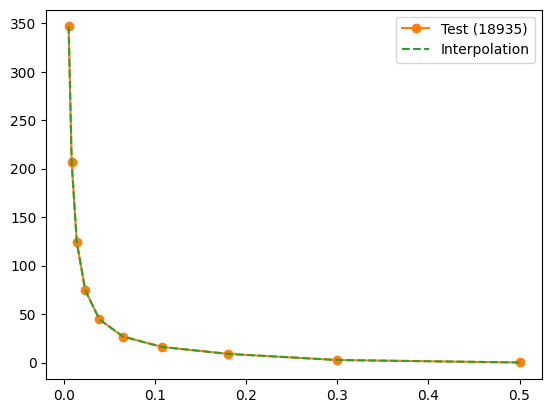

In [177]:
# Plot the interpolation and origional data.
plt.plot(sigmas, target_frac_score_norms, 'C1-o', label='Test (18935)')
plt.plot(sigmas, frac_score_norms_interp(sigmas), 'C2--', label='Interpolation')
plt.legend()

In [188]:
# Save the interpolation.
with open('./test_models/frac_score_norms_interp.pkl', 'wb') as f:
    pickle.dump(frac_score_norms_interp, f)

In [9]:
# Load the interpolation.
with open('./test_models/frac_score_norms_interp.pkl', 'rb') as f:
    frac_score_norms_interp = pickle.load(f)

In [27]:
frac_score_norms_interp(torch.tensor([0.3,0.5]).reshape(-1,2).T)

array([[2.6381244 ],
       [0.11061516]])